## CNN Implementation

Total parameters: 225,034
Epoch  1 | Train: 95.07% | Test: 98.52%
Epoch  2 | Train: 98.42% | Test: 98.71%
Epoch  3 | Train: 98.83% | Test: 99.03%
Epoch  4 | Train: 99.10% | Test: 98.91%
Epoch  5 | Train: 99.30% | Test: 99.15%
Epoch  6 | Train: 99.37% | Test: 99.11%
Epoch  7 | Train: 99.50% | Test: 99.23%
Epoch  8 | Train: 99.50% | Test: 99.07%
Epoch  9 | Train: 99.61% | Test: 99.15%
Epoch 10 | Train: 99.63% | Test: 99.28%


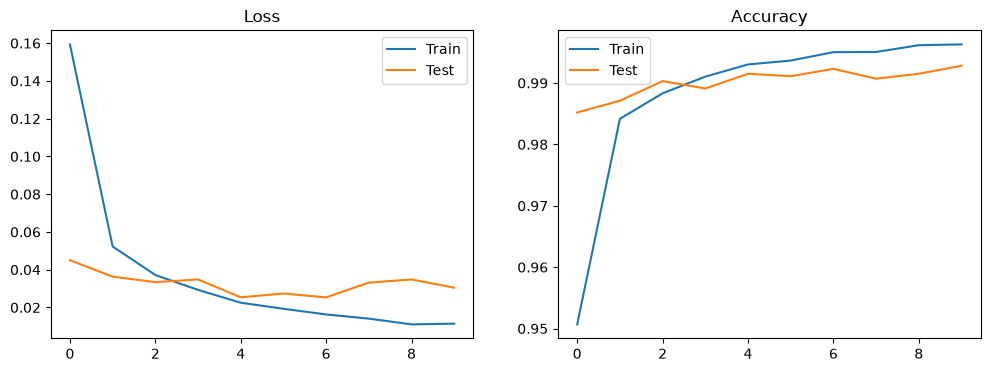

In [ ]:
# importing the libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# same data pipeline as before
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST('./data', train=True,
                                download=True, transform=transform)
test_dataset = datasets.MNIST('./data', train=False,
                               transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# cnn
class MNISTConvNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3),   # 1 input channel, 32 filters
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3),  # 32 input channels, 64 filters
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*5*5, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

model = MNISTConvNet()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# counting parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    correct = 0
    for X_batch, y_batch in loader:
        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct += (output.argmax(1) == y_batch).sum().item()
    return total_loss/len(loader), correct/len(loader.dataset)

def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    correct = 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            output = model(X_batch)
            loss = criterion(output, y_batch)
            total_loss += loss.item()
            correct += (output.argmax(1) == y_batch).sum().item()
    return total_loss/len(loader), correct/len(loader.dataset)

# training
train_losses, test_losses = [], []
train_accs, test_accs = [], []

for epoch in range(10):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
    test_loss, test_acc = evaluate(model, test_loader, criterion)
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)
    print(f"Epoch {epoch+1:2d} | Train: {train_acc*100:.2f}% | Test: {test_acc*100:.2f}%")

# plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(train_losses, label='Train')
axes[0].plot(test_losses, label='Test')
axes[0].set_title('Loss')
axes[0].legend()
axes[1].plot(train_accs, label='Train')
axes[1].plot(test_accs, label='Test')
axes[1].set_title('Accuracy')
axes[1].legend()
plt.show()